In [1]:
from helper_functions import LSE, construct_R, decomp_orthog
import numpy as np
import gurobipy as gp
from gurobipy import GRB
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt  

In [3]:
#We need to calculate the adjusted R^2 for each model after clustering. This adjusted R^2 is for the case where there is NO INTERCEPT.
def adjusted_r2(mod_matrix,coeff,response):

    n = len(response)
    p = len(coeff)
    rss = np.sum(np.square(mod_matrix@coeff - response))
    tss = np.sum(np.square(response))

    r2 = 1 - rss/tss

    adj_r2 = 1 - ((1-r2)*(n)/(n-p))

    return adj_r2

In [5]:
#This function takes the scaling factors from decomp_orthog and multiplies them by the LSE estimates to get the scaled coefficients.
def decomp_scaled_coefficients(theta,lse_coeff):
    #Theta: this should be an MxJ numpy array of scaling factors obtained from decomp_orthog.
    #lse_coeff: this should be an MxJ numpy array of estimated coefficients coming from LSE, and should be the LSE estimates used in constructing matrices R_1,...
    #R_J for decomp_orthog.

    return theta*lse_coeff

In [ ]:
#Bertin Plot for true structure
bertin_data_true = {
    "d" : [1,1,1,1,1,1,1,1,1,1],
    "D" : [0,0,0,0,1,1,1,0,1,1],
    "Pc" : [1,0,0,0,0,0,0,1,0,0],
    "\u03C1" : [0,0,1,1,0,1,1,1,0,0],
    "q" : [0,0,1,1,0,1,1,1,0,0],
    "F" : [0,0,0,0,1,0,0,0,0,0],
    "G" : [0,0,0,0,0,1,1,0,0,0],
    "Li" : [0,0,0,0,0,0,0,1,0,0]
}

index_labels_true = ["Fc", "\u03B4", "Fd", "R","S","N","Ls","Lf","K","C"]

bertin_true_df = pd.DataFrame(bertin_data_true, index=index_labels_true)

plt.figure(figsize=(8, 6))
sns.heatmap(bertin_true_df, annot=True, cmap="Greys", cbar=False, linewidths=0.5, linecolor="black")

# Add labels and title
plt.title("True Structure of Spring Design Problem", fontsize=16)
plt.xlabel("Variables")
plt.ylabel("Responses")
plt.savefig("true_structure.png")
plt.show()

In [7]:
x_data = pd.read_csv('xdata.csv')
y_data = pd.read_csv('ydata.csv')
print(y_data)
print(y_data.mean())
print(y_data.std())
y_data = (y_data - y_data.mean())/y_data.std()
print(x_data)
print(y_data)
print(y_data.mean())
print(y_data.std())

    Unnamed: 0        V1        V2         V3         V4         V5  \
0            1  3.568422 -2.896909   9.574069  12.470978  13.207625   
1            2  2.571462 -2.335912   9.851322  12.187234  10.922157   
2            3  3.558387 -2.910714  11.500348  14.411062  13.298580   
3            4  2.164767 -2.453434  10.026582  12.480016  11.470825   
4            5  2.391912 -2.734207  11.520736  14.254943  11.816705   
..         ...       ...       ...        ...        ...        ...   
95          96  4.579524 -2.114892  10.940452  13.055345  10.715378   
96          97  2.668078 -2.865983  12.481353  15.347335  11.681872   
97          98  3.409815 -2.946411   6.968600   9.915011  12.909618   
98          99  3.404572 -2.587067   2.840587   5.427654  10.315172   
99         100  4.084791 -2.475603  11.508836  13.984439  10.500535   

           V6        V7        V8        V9       V10  
0  -34.989589 -0.817468  2.748335  0.107899  2.526414  
1  -32.332748 -0.256470  2.614449  

In [9]:
model_matrix = x_data.iloc[:,1:9].to_numpy()
#print(design_matrix)
model_matrix_with_intercept = np.concatenate((np.ones((100,1)),model_matrix),axis = 1)
print(model_matrix_with_intercept)

[[ 1.00000000e+00 -9.05978366e-01  8.01306704e-01  8.51146170e-01
   2.85852795e-02 -5.80020531e-01  4.37651855e-01  1.10268803e-01
   1.23293880e-01]
 [ 1.00000000e+00  2.27911908e-01  7.15107369e-01 -7.95346533e-01
   1.15829249e-01 -1.34606771e-01 -3.57779709e-01  8.02056380e-01
  -2.68074414e-01]
 [ 1.00000000e+00 -9.26639452e-01  2.58004325e-01  8.84324904e-01
   4.87731040e-01  1.13932685e-01  9.90753718e-01  1.40419491e-01
   7.48014571e-01]
 [ 1.00000000e+00 -6.49075299e-02 -1.26135261e-01 -8.30812086e-01
  -9.76292634e-01 -1.54693286e-01  3.34657017e-01 -4.19490240e-01
  -3.67967108e-02]
 [ 1.00000000e+00 -6.39713564e-01 -7.31743311e-01 -6.03446769e-01
   9.13685085e-01  3.43085535e-01  3.09353354e-01 -1.58498378e-01
   2.63144023e-01]
 [ 1.00000000e+00 -2.10121483e-01 -8.10677977e-02  4.83527706e-01
   8.60271136e-01  4.51229443e-01 -1.22784675e-01  3.66501480e-02
   1.56605564e-01]
 [ 1.00000000e+00 -2.86250543e-01  1.07325289e-03 -5.55017048e-01
   8.83184117e-01  5.5312601

In [11]:
R1,LSE1 = construct_R(model_matrix_with_intercept,y_data.iloc[:,1].to_numpy().reshape(100,))
R2,LSE2 = construct_R(model_matrix_with_intercept,y_data.iloc[:,2].to_numpy().reshape(100,))
R3,LSE3 = construct_R(model_matrix_with_intercept,y_data.iloc[:,3].to_numpy().reshape(100,))
R4,LSE4 = construct_R(model_matrix_with_intercept,y_data.iloc[:,4].to_numpy().reshape(100,))
R5,LSE5 = construct_R(model_matrix_with_intercept,y_data.iloc[:,5].to_numpy().reshape(100,))
R6,LSE6 = construct_R(model_matrix_with_intercept,y_data.iloc[:,6].to_numpy().reshape(100,))
R7,LSE7 = construct_R(model_matrix_with_intercept,y_data.iloc[:,7].to_numpy().reshape(100,))
R8,LSE8 = construct_R(model_matrix_with_intercept,y_data.iloc[:,8].to_numpy().reshape(100,))
R9,LSE9 = construct_R(model_matrix_with_intercept,y_data.iloc[:,9].to_numpy().reshape(100,))
R10,LSE10 = construct_R(model_matrix_with_intercept,y_data.iloc[:,10].to_numpy().reshape(100,))
print(LSE1)
print(LSE2)
print(LSE10)

[ 4.10366335e-04  8.48848150e-01 -7.46370731e-02  1.46128211e+00
  1.59219157e-01 -7.19589989e-02 -5.23585433e-02  7.09184320e-02
  4.43909982e-02]
[ 4.05246717e-04  1.71188354e+00  5.86532146e-03 -1.37289532e-02
 -2.52902573e-03 -2.98209018e-04 -3.28708789e-02 -5.15185998e-03
  2.29082356e-02]
[ 3.42973442e-04 -8.40934612e-01  1.45538028e+00 -1.45611108e-02
 -2.24121792e-02  3.17895664e-02  4.63511021e-02 -1.47025135e-02
 -3.23175466e-02]


In [13]:
Y_1 = y_data.iloc[:,1].to_numpy().reshape(100,) - LSE1[0]
Y_2 = y_data.iloc[:,2].to_numpy().reshape(100,) - LSE2[0]
Y_3 = y_data.iloc[:,3].to_numpy().reshape(100,) - LSE3[0]
Y_4 = y_data.iloc[:,4].to_numpy().reshape(100,) - LSE4[0]
Y_5 = y_data.iloc[:,5].to_numpy().reshape(100,) - LSE5[0]
Y_6 = y_data.iloc[:,6].to_numpy().reshape(100,) - LSE6[0]
Y_7 = y_data.iloc[:,7].to_numpy().reshape(100,) - LSE7[0]
Y_8 = y_data.iloc[:,8].to_numpy().reshape(100,) - LSE8[0]
Y_9 = y_data.iloc[:,9].to_numpy().reshape(100,) - LSE9[0]
Y_10 = y_data.iloc[:,10].to_numpy().reshape(100,) - LSE10[0]
print(Y_1)

[-0.0031443  -1.04282794 -0.01360986 -1.46695075 -1.23007174  0.56058186
 -0.73632044 -0.07957343  1.59600795  1.05906747  1.69253706  0.6030748
  0.31648111  0.34682801 -0.26321364 -1.64568459 -1.10419917 -1.53559638
  0.65559706  0.83670257  0.04152646  0.15741543  0.10223022  1.2285232
 -0.63559719 -0.13540549  0.79891805  0.22712137  1.14977977 -1.54469061
  0.51937775  0.40745739 -0.15250104  0.67186266 -0.0029372  -0.21516479
 -1.00822133  0.94953266  0.09872697  0.47021542 -0.11923468 -2.50137641
 -0.92114407  1.11537856  0.93203657  1.09503432 -2.89322488  0.36065314
  0.58208504 -0.24676481 -2.61985219 -0.54888937  1.39852488 -0.04282592
 -1.93387556  0.81671461 -1.95644419  0.58391805 -0.07799183  0.54733771
 -0.13943897 -0.0642783   1.27865395  1.15829834  0.20101202  1.31542034
 -0.44340047 -0.19090816  1.00595843 -1.13079504 -0.09758539  0.65451316
 -0.36605842  1.10226837  1.40246116 -0.03623268 -0.44066441  0.13309769
 -0.66452326 -1.91532323  0.74459794  0.75852495 -1.6

In [15]:
R1_noint,LSE1_noint = construct_R(model_matrix,Y_1)
R2_noint,LSE2_noint = construct_R(model_matrix,Y_2)
R3_noint,LSE3_noint = construct_R(model_matrix,Y_3)
R4_noint,LSE4_noint = construct_R(model_matrix,Y_4)
R5_noint,LSE5_noint = construct_R(model_matrix,Y_5)
R6_noint,LSE6_noint = construct_R(model_matrix,Y_6)
R7_noint,LSE7_noint = construct_R(model_matrix,Y_7)
R8_noint,LSE8_noint = construct_R(model_matrix,Y_8)
R9_noint,LSE9_noint = construct_R(model_matrix,Y_9)
R10_noint,LSE10_noint = construct_R(model_matrix,Y_10)
print(LSE1_noint)
print(LSE2_noint)
print(LSE3_noint)
print(LSE4_noint)
print(LSE5_noint)
print(LSE6_noint)
print(LSE7_noint)
print(LSE8_noint)
print(LSE9_noint)
print(LSE10_noint)

[ 0.84884815 -0.07463707  1.46128211  0.15921916 -0.071959   -0.05235854
  0.07091843  0.044391  ]
[ 1.71188354e+00  5.86532146e-03 -1.37289532e-02 -2.52902573e-03
 -2.98209018e-04 -3.28708789e-02 -5.15185998e-03  2.29082356e-02]
[-0.35039467 -0.1608367   0.00808084 -0.06223976  1.47278718  0.24188845
 -0.06303091  0.00811442]
[-0.57391037 -0.15734008  0.00973266 -0.06023386  1.43350286  0.23990129
 -0.0606471   0.00478149]
[-1.18565191  0.48356959  0.00956941  0.0328617   0.04026468  1.02158916
  0.04013106 -0.00545981]
[ 1.10497458e+00 -7.69439358e-01  3.27567011e-04  5.76735462e-02
 -1.07337068e+00 -2.07886347e-01  6.15040357e-02  1.84385389e-02]
[ 1.71188354e+00  5.86532146e-03 -1.37289532e-02 -2.52902573e-03
 -2.98209019e-04 -3.28708789e-02 -5.15185998e-03  2.29082356e-02]
[ 8.09481307e-03  2.79663324e-02  9.23709280e-04  3.76928146e-02
  1.25190921e-02 -4.61147553e-02 -1.33949441e-02  1.72789800e+00]
[ 0.73340951 -1.3961189   0.12438797 -0.00380157 -0.15790724 -0.03223605
  0.095

In [17]:
heredity = [[[] for j in range(8)] for i in range(10)]
print(heredity)

[[[], [], [], [], [], [], [], []], [[], [], [], [], [], [], [], []], [[], [], [], [], [], [], [], []], [[], [], [], [], [], [], [], []], [[], [], [], [], [], [], [], []], [[], [], [], [], [], [], [], []], [[], [], [], [], [], [], [], []], [[], [], [], [], [], [], [], []], [[], [], [], [], [], [], [], []], [[], [], [], [], [], [], [], []]]


In [19]:
responses = np.array([Y_1,Y_2,Y_3,Y_4,Y_5,Y_6,Y_7,Y_8,Y_9,Y_10])
print(responses)
#print(y_data.iloc[:,1:11].to_numpy())
#print(responses)

[[-3.14430240e-03 -1.04282794e+00 -1.36098613e-02 -1.46695075e+00
  -1.23007174e+00  5.60581864e-01 -7.36320440e-01 -7.95734264e-02
   1.59600795e+00  1.05906747e+00  1.69253706e+00  6.03074805e-01
   3.16481109e-01  3.46828013e-01 -2.63213635e-01 -1.64568459e+00
  -1.10419917e+00 -1.53559638e+00  6.55597056e-01  8.36702567e-01
   4.15264562e-02  1.57415430e-01  1.02230223e-01  1.22852320e+00
  -6.35597193e-01 -1.35405491e-01  7.98918051e-01  2.27121375e-01
   1.14977977e+00 -1.54469061e+00  5.19377750e-01  4.07457389e-01
  -1.52501039e-01  6.71862665e-01 -2.93719650e-03 -2.15164792e-01
  -1.00822133e+00  9.49532658e-01  9.87269703e-02  4.70215423e-01
  -1.19234683e-01 -2.50137641e+00 -9.21144070e-01  1.11537856e+00
   9.32036567e-01  1.09503432e+00 -2.89322488e+00  3.60653138e-01
   5.82085039e-01 -2.46764812e-01 -2.61985219e+00 -5.48889366e-01
   1.39852488e+00 -4.28259231e-02 -1.93387556e+00  8.16714607e-01
  -1.95644419e+00  5.83918054e-01 -7.79918301e-02  5.47337708e-01
  -1.39438

In [21]:
decomp_fit_2 = decomp_orthog(responses,[R1_noint,R2_noint,R3_noint,R4_noint,R5_noint,R6_noint,R7_noint,R8_noint,R9_noint,R10_noint],heredity,2,t=300,focus=0,outputflag = 1)
print(decomp_fit_2)

Set parameter Username
Set parameter LicenseID to value 2661045
Academic license - for non-commercial use only - expires 2026-05-05
Set parameter TimeLimit to value 300
Set parameter MIPFocus to value 0
Set parameter OutputFlag to value 1
Gurobi Optimizer version 12.0.1 build v12.0.1rc0 (win64 - Windows 11.0 (26100.2))

CPU model: Intel(R) Core(TM) Ultra 7 258V, instruction set [SSE2|AVX|AVX2]
Thread count: 8 physical cores, 8 logical processors, using up to 8 threads

Non-default parameters:
TimeLimit  300

Optimize a model with 12 rows, 190 columns and 40 nonzeros
Model fingerprint: 0x7b3058b5
Model has 360 quadratic objective terms
Model has 135 quadratic constraints
Variable types: 125 continuous, 65 integer (65 binary)
Coefficient statistics:
  Matrix range     [1e+00, 1e+00]
  QMatrix range    [1e+00, 1e+00]
  QLMatrix range   [1e+00, 1e+00]
  Objective range  [3e-03, 2e+02]
  QObjective range [3e-06, 2e+02]
  Bounds range     [1e+00, 4e+02]
  RHS range        [1e+00, 1e+00]
  QR

In [ ]:
decomp_fit_4 = decomp_orthog(responses,[R1_noint,R2_noint,R3_noint,R4_noint,R5_noint,R6_noint,R7_noint,R8_noint,R9_noint,R10_noint],heredity,4,t=300,focus=0,outputflag = 1)
print(decomp_fit_4)

In [ ]:
decomp_fit_6 = decomp_orthog(responses,[R1_noint,R2_noint,R3_noint,R4_noint,R5_noint,R6_noint,R7_noint,R8_noint,R9_noint,R10_noint],heredity,6,t=600,focus=0,outputflag = 1)
print(decomp_fit_6)

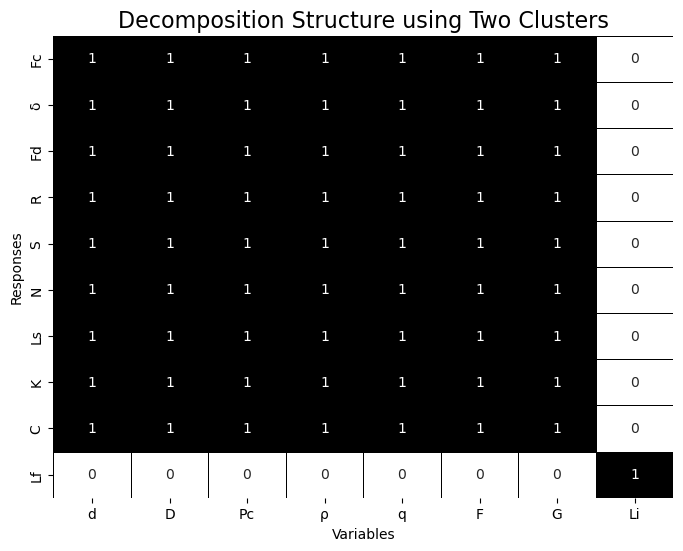

[[ 8.44198747e-01  1.70948419e+00 -3.51244544e-01 -5.74411164e-01
  -1.18508006e+00  1.10304337e+00  1.70948419e+00  0.00000000e+00
   7.24760805e-01 -8.37549740e-01]
 [-7.28931511e-02  6.76530536e-03 -1.60517923e-01 -1.57152232e-01
   4.83355098e-01 -7.68714980e-01  6.76530536e-03  0.00000000e+00
  -1.39287489e+00  1.45411067e+00]
 [ 1.46285311e+00 -1.29182377e-02  8.36801149e-03  9.90187632e-03
   9.37619145e-03  9.79965651e-04 -1.29182377e-02  0.00000000e+00
   1.27310289e-01 -1.57048215e-02]
 [ 1.54891703e-01 -4.76224627e-03 -6.30307981e-02 -6.06999958e-02
   3.33939309e-02  5.58760384e-02 -4.76224627e-03  0.00000000e+00
  -1.18513550e-02 -1.92617258e-02]
 [-7.45639551e-02 -1.64230068e-03  1.47231101e+00  1.43322227e+00
   4.05850726e-02 -1.07445269e+00 -1.64230068e-03  0.00000000e+00
  -1.62752915e-01  3.36860223e-02]
 [-4.49908087e-02 -2.90687435e-02  2.43235242e-01  2.40694906e-01
   1.02068300e+00 -2.04826038e-01 -2.90687435e-02 -0.00000000e+00
  -1.85307895e-02  4.09872696e-02

In [23]:
#Two clusters
#Bertin Plot for two clusters
bertin_data_two = {
    "d" : [1,1,1,1,1,1,1,1,1,0],
    "D" : [1,1,1,1,1,1,1,1,1,0],
    "Pc" : [1,1,1,1,1,1,1,1,1,0],
    "\u03C1" : [1,1,1,1,1,1,1,1,1,0],
    "q" : [1,1,1,1,1,1,1,1,1,0],
    "F" : [1,1,1,1,1,1,1,1,1,0],
    "G" : [1,1,1,1,1,1,1,1,1,0],
    "Li" : [0,0,0,0,0,0,0,0,0,1]
}

index_labels_two = ["Fc","\u03B4","Fd","R","S","N","Ls","K","C","Lf"]

bertin_two_df = pd.DataFrame(bertin_data_two, index=index_labels_two)

plt.figure(figsize=(8, 6))
sns.heatmap(bertin_two_df, annot=True, cmap="Greys", cbar=False, linewidths=0.5, linecolor="black")

# Add labels and title
plt.title("Decomposition Structure using Two Clusters", fontsize=16)
plt.xlabel("Variables")
plt.ylabel("Responses")
plt.savefig("two_clusters.png")
plt.show()

#Get models and adjusted R^2 values
decomp_coeff_2 = decomp_scaled_coefficients(decomp_fit_2[0].T,np.array([LSE1_noint,LSE2_noint,LSE3_noint,LSE4_noint,LSE5_noint,LSE6_noint,LSE7_noint,LSE8_noint,LSE9_noint,LSE10_noint]).T)
print(decomp_coeff_2)

print('Fc LSE:'+str(adjusted_r2(model_matrix,LSE1_noint,Y_1)))
print('Fc Decomp:'+str(adjusted_r2(model_matrix,decomp_coeff_2[:,0],Y_1)))

print('delta LSE:'+str(adjusted_r2(model_matrix,LSE2_noint,Y_2)))
print('delta Decomp:'+str(adjusted_r2(model_matrix,decomp_coeff_2[:,1],Y_2)))

print('Fd LSE:'+str(adjusted_r2(model_matrix,LSE3_noint,Y_3)))
print('Fd Decomp:'+str(adjusted_r2(model_matrix,decomp_coeff_2[:,2],Y_3)))

print('R LSE:'+str(adjusted_r2(model_matrix,LSE4_noint,Y_4)))
print('R Decomp:'+str(adjusted_r2(model_matrix,decomp_coeff_2[:,3],Y_4)))

print('S LSE:'+str(adjusted_r2(model_matrix,LSE5_noint,Y_5)))
print('S Decomp:'+str(adjusted_r2(model_matrix,decomp_coeff_2[:,4],Y_5)))

print('N LSE:'+str(adjusted_r2(model_matrix,LSE6_noint,Y_6)))
print('N Decomp:'+str(adjusted_r2(model_matrix,decomp_coeff_2[:,5],Y_6)))

print('Ls LSE:'+str(adjusted_r2(model_matrix,LSE7_noint,Y_7)))
print('Ls Decomp:'+str(adjusted_r2(model_matrix,decomp_coeff_2[:,6],Y_7)))

print('Lf LSE:'+str(adjusted_r2(model_matrix,LSE8_noint,Y_8)))
print('Lf Decomp:'+str(adjusted_r2(model_matrix,decomp_coeff_2[:,7],Y_8)))

print('K LSE:'+str(adjusted_r2(model_matrix,LSE9_noint,Y_9)))
print('K Decomp:'+str(adjusted_r2(model_matrix,decomp_coeff_2[:,8],Y_9)))

print('C LSE:'+str(adjusted_r2(model_matrix,LSE10_noint,Y_10)))
print('C Decomp:'+str(adjusted_r2(model_matrix,decomp_coeff_2[:,9],Y_10)))

In [ ]:
#Four clusters
#Bertin Plot for four clusters
bertin_data_four = {
    "Pc" : [1,0,0,0,0,0,0,0,0,0],
    "\u03C1" : [1,0,0,0,0,0,0,0,0,0],
    "q" : [0,1,1,0,0,0,0,0,0,0],
    "Li" : [0,0,0,1,0,0,0,0,0,0],
    "d" : [0,0,0,0,1,1,1,1,1,1],
    "D" : [0,0,0,0,1,1,1,1,1,1],
    "F" : [0,0,0,0,1,1,1,1,1,1],
    "G" : [0,0,0,0,1,1,1,1,1,1]
}

index_labels_four = ["Fc","Fd","R","Lf","\u03B4","S","N","Ls","K","C"]

bertin_four_df = pd.DataFrame(bertin_data_four, index=index_labels_four)

plt.figure(figsize=(8, 6))
sns.heatmap(bertin_four_df, annot=True, cmap="Greys", cbar=False, linewidths=0.5, linecolor="black")

# Add labels and title
plt.title("Decomposition Structure using Four Clusters", fontsize=16)
plt.xlabel("Variables")
plt.ylabel("Responses")
plt.savefig("four_clusters.png")
plt.show()

#Get models and adjusted R^2 values
decomp_coeff_4 = decomp_scaled_coefficients(decomp_fit_4[0].T,np.array([LSE1_noint,LSE2_noint,LSE3_noint,LSE4_noint,LSE5_noint,LSE6_noint,LSE7_noint,LSE8_noint,LSE9_noint,LSE10_noint]).T)
print(decomp_coeff_4)

print('Fc LSE:'+str(adjusted_r2(model_matrix,LSE1_noint,Y_1)))
print('Fc Decomp:'+str(adjusted_r2(model_matrix,decomp_coeff_4[:,0],Y_1)))

print('delta LSE:'+str(adjusted_r2(model_matrix,LSE2_noint,Y_2)))
print('delta Decomp:'+str(adjusted_r2(model_matrix,decomp_coeff_4[:,1],Y_2)))

print('Fd LSE:'+str(adjusted_r2(model_matrix,LSE3_noint,Y_3)))
print('Fd Decomp:'+str(adjusted_r2(model_matrix,decomp_coeff_4[:,2],Y_3)))

print('R LSE:'+str(adjusted_r2(model_matrix,LSE4_noint,Y_4)))
print('R Decomp:'+str(adjusted_r2(model_matrix,decomp_coeff_4[:,3],Y_4)))

print('S LSE:'+str(adjusted_r2(model_matrix,LSE5_noint,Y_5)))
print('S Decomp:'+str(adjusted_r2(model_matrix,decomp_coeff_4[:,4],Y_5)))

print('N LSE:'+str(adjusted_r2(model_matrix,LSE6_noint,Y_6)))
print('N Decomp:'+str(adjusted_r2(model_matrix,decomp_coeff_4[:,5],Y_6)))

print('Ls LSE:'+str(adjusted_r2(model_matrix,LSE7_noint,Y_7)))
print('Ls Decomp:'+str(adjusted_r2(model_matrix,decomp_coeff_4[:,6],Y_7)))

print('Lf LSE:'+str(adjusted_r2(model_matrix,LSE8_noint,Y_8)))
print('Lf Decomp:'+str(adjusted_r2(model_matrix,decomp_coeff_4[:,7],Y_8)))

print('K LSE:'+str(adjusted_r2(model_matrix,LSE9_noint,Y_9)))
print('K Decomp:'+str(adjusted_r2(model_matrix,decomp_coeff_4[:,8],Y_9)))

print('C LSE:'+str(adjusted_r2(model_matrix,LSE10_noint,Y_10)))
print('C Decomp:'+str(adjusted_r2(model_matrix,decomp_coeff_4[:,9],Y_10)))

In [ ]:
#six clusters
#Bertin Plot for six clusters
bertin_data_six = {
    "Pc" : [1,0,0,0,0,0,0,0,0,0],
    "d" : [0,1,1,1,1,1,0,0,0,0],
    "\u03C1" : [0,1,0,0,1,1,0,0,0,0],
    "q" : [0,1,1,1,1,1,0,0,0,0],
    "D" : [0,0,0,0,0,0,1,0,0,0],
    "F" : [0,0,0,0,0,0,0,0,1,0],
    "G" : [0,0,0,0,0,0,0,0,1,0],
    "Li" : [0,0,0,0,0,0,0,0,0,1]
}

index_labels_six = ["Fc","\u03B4","Fd","R","N","Ls","C","K","S","Lf"]

bertin_six_df = pd.DataFrame(bertin_data_six, index=index_labels_six)

plt.figure(figsize=(8, 6))
sns.heatmap(bertin_six_df, annot=True, cmap="Greys", cbar=False, linewidths=0.5, linecolor="black")

# Add labels and title
plt.title("Decomposition Structure using Six Clusters", fontsize=16)
plt.xlabel("Variables")
plt.ylabel("Responses")
plt.savefig("six_clusters.png")
plt.show()

#Get models and adjusted R^2 values
decomp_coeff_6 = decomp_scaled_coefficients(decomp_fit_6[0].T,np.array([LSE1_noint,LSE2_noint,LSE3_noint,LSE4_noint,LSE5_noint,LSE6_noint,LSE7_noint,LSE8_noint,LSE9_noint,LSE10_noint]).T)
print(decomp_coeff_6)

print('Fc LSE:'+str(adjusted_r2(model_matrix,LSE1_noint,Y_1)))
print('Fc Decomp:'+str(adjusted_r2(model_matrix,decomp_coeff_6[:,0],Y_1)))

print('delta LSE:'+str(adjusted_r2(model_matrix,LSE2_noint,Y_2)))
print('delta Decomp:'+str(adjusted_r2(model_matrix,decomp_coeff_6[:,1],Y_2)))

print('Fd LSE:'+str(adjusted_r2(model_matrix,LSE3_noint,Y_3)))
print('Fd Decomp:'+str(adjusted_r2(model_matrix,decomp_coeff_6[:,2],Y_3)))

print('R LSE:'+str(adjusted_r2(model_matrix,LSE4_noint,Y_4)))
print('R Decomp:'+str(adjusted_r2(model_matrix,decomp_coeff_6[:,3],Y_4)))

print('S LSE:'+str(adjusted_r2(model_matrix,LSE5_noint,Y_5)))
print('S Decomp:'+str(adjusted_r2(model_matrix,decomp_coeff_6[:,4],Y_5)))

print('N LSE:'+str(adjusted_r2(model_matrix,LSE6_noint,Y_6)))
print('N Decomp:'+str(adjusted_r2(model_matrix,decomp_coeff_6[:,5],Y_6)))

print('Ls LSE:'+str(adjusted_r2(model_matrix,LSE7_noint,Y_7)))
print('Ls Decomp:'+str(adjusted_r2(model_matrix,decomp_coeff_6[:,6],Y_7)))

print('Lf LSE:'+str(adjusted_r2(model_matrix,LSE8_noint,Y_8)))
print('Lf Decomp:'+str(adjusted_r2(model_matrix,decomp_coeff_6[:,7],Y_8)))

print('K LSE:'+str(adjusted_r2(model_matrix,LSE9_noint,Y_9)))
print('K Decomp:'+str(adjusted_r2(model_matrix,decomp_coeff_6[:,8],Y_9)))

print('C LSE:'+str(adjusted_r2(model_matrix,LSE10_noint,Y_10)))
print('C Decomp:'+str(adjusted_r2(model_matrix,decomp_coeff_6[:,9],Y_10)))

In [ ]:
print(LSE7)
print(LSE2)
print(Y_2)
print(Y_7)
print(y_data.iloc[:,2].to_numpy().reshape(100,))
print(y_data.iloc[:,7].to_numpy().reshape(100,))
print(y_data)